# Spotify Streaming Era Analysis

## Project Overview

This project analyzes the streaming performance, chart dominance, longevity, stability, geographic reach, and overall career strength of a selected group of globally recognized artists using Spotify chart data.

Rather than evaluating artists through a single measurement such as total streams, this analysis combines multiple performance dimensions, including streaming power, chart performance, career longevity, trajectory strength, dominance, and audience reach. These metrics are integrated into a multi-dimensional ranking framework designed to evaluate long-term artist impact during the Spotify streaming era.

The study covers Spotify chart activity from **2017-01-01 to 2026-05-28**, spanning **73 countries**, **13 selected artists**, and more than **1.7 million streaming observations** after extraction and filtering.

Through large-scale data processing, feature engineering, statistical analysis, and visualization, this project examines how artists achieve streaming success, maintain chart presence, sustain audience engagement, and demonstrate long-term influence in the modern music industry.

---

## Era Context

This analysis evaluates artist performance within the modern Spotify streaming ecosystem. Because the selected artists come from different musical eras, differences in streaming availability, platform adoption, and audience behavior should be considered when interpreting the results. The ranking reflects streaming-era performance based on measured metrics rather than a complete evaluation of overall artist legacy.

---

# Artists Included

- Taylor Swift
- Rihanna
- Adele
- Eminem
- Bruno Mars
- Lady Gaga
- Beyoncé
- Michael Jackson
- The Beatles
- The Rolling Stones
- Elvis Presley
- Whitney Houston
- The Weeknd

---

# Analysis Objectives

- Measure total streaming performance across Spotify charts.
- Evaluate artist dominance through chart achievements and global presence.
- Analyze career longevity and sustained chart activity.
- Measure streaming trajectory and career evolution over time.
- Examine stability and consistency of artist performance.
- Compare global streaming distribution across countries.
- Develop a data-driven career ranking framework using statistical methods.
- Generate an overall artist ranking using a multi-criteria scoring approach.

---

# Methodology Overview

The analysis pipeline includes:

- Data cleaning and artist normalization.
- Target artists identified through normalized artist name matching against a predefined target set.
- Aggregation of streaming metrics at the artist level.
- Feature engineering across multiple career dimensions.
- Standardization of metrics for comparison.
- PCA analysis to determine feature contribution and importance.
- TOPSIS ranking to calculate final career scores.
- Visualization of streaming performance, geographic reach, career trajectories, and final rankings.

In [1]:
import pandas as pd, numpy as np, re, gc
import matplotlib.pyplot as plt, seaborn as sns
import pycountry
import os
import ast
import unicodedata
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from functools import reduce
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import FuncFormatter
from rapidfuzz import process
from ast import literal_eval
from IPython.display import clear_output
from IPython.display import Markdown, display

FILE_PATH="charts_songs_daily.csv"
ALIAS_PATH="aliases.csv"
CHUNK_SIZE=100000

In [2]:
TARGET_ARTISTS = [
"Taylor Swift","Adele","Eminem","The Rolling Stones",
"Bruno Mars","Whitney Houston","The Beatles","The Weeknd",
"Michael Jackson","Rihanna","Beyoncé","Lady Gaga","Elvis Presley"]

def norm(x):
    x = str(x).lower().strip()
    x = unicodedata.normalize("NFKD", x).encode("ascii","ignore").decode("utf-8")
    return x
TARGET_SET = set(norm(a) for a in TARGET_ARTISTS)

In [3]:
COUNTRY_MAP = {
'ae':'United Arab Emirates','ar':'Argentina','at':'Austria','au':'Australia',
'be':'Belgium','bg':'Bulgaria','bo':'Bolivia','br':'Brazil','by':'Belarus',
'ca':'Canada','ch':'Switzerland','cl':'Chile','co':'Colombia','cr':'Costa Rica',
'cz':'Czech Republic','de':'Germany','dk':'Denmark','do':'Dominican Republic',
'ec':'Ecuador','ee':'Estonia','eg':'Egypt','es':'Spain','fi':'Finland',
'fr':'France','gb':'United Kingdom','global':'Global','gr':'Greece','gt':'Guatemala',
'hk':'Hong Kong','hn':'Honduras','hu':'Hungary','id':'Indonesia','ie':'Ireland',
'il':'Israel','in':'India','is':'Iceland','it':'Italy','jp':'Japan','kr':'South Korea',
'kz':'Kazakhstan','lt':'Lithuania','lu':'Luxembourg','lv':'Latvia','ma':'Morocco',
'mx':'Mexico','my':'Malaysia','ng':'Nigeria','ni':'Nicaragua','nl':'Netherlands',
'no':'Norway','nz':'New Zealand','pa':'Panama','pe':'Peru','ph':'Philippines',
'pk':'Pakistan','pl':'Poland','pt':'Portugal','py':'Paraguay','ro':'Romania',
'sa':'Saudi Arabia','se':'Sweden','sg':'Singapore','sk':'Slovakia','sv':'El Salvador',
'th':'Thailand','tr':'Turkey','tw':'Taiwan','ua':'Ukraine','us':'United States',
'uy':'Uruguay','ve':'Venezuela','vn':'Vietnam','za':'South Africa'
}

In [4]:
def norm_country(x):
    x = str(x).strip().lower()
    return COUNTRY_MAP.get(x, "Unknown")

In [5]:
aliases = pd.read_csv(ALIAS_PATH)
aliases.columns = aliases.columns.str.lower()
csv_aliases = dict(zip(
    aliases["alias"].str.lower(),
    aliases["canonical"].str.lower()))

INLINE_ALIASES = {
    "the weeknd": "the weeknd",
    "abel tesfaye": "the weeknd",

    "lady gaga": "lady gaga",

    "beyonce": "beyonce",
    "beyonce knowles": "beyonce",
    "beyoncé": "beyonce",

    "rihanna": "rihanna",
    "robyn rihanna fenty": "rihanna",

    "eminem": "eminem",
    "marshall mathers": "eminem",

    "bruno mars": "bruno mars",

    "taylor swift": "taylor swift",
    "taylor alison swift": "taylor swift",

    "adele": "adele",

    "michael jackson": "michael jackson",

    "whitney houston": "whitney houston",
    "witney houston": "whitney houston",

    "the rolling stones": "the rolling stones",

    "elvis presley": "elvis presley",

    "die beatles": "the beatles",
    "the beatles": "the beatles"
}
ALIAS_MAP = {**INLINE_ALIASES, **csv_aliases}

In [6]:
def normalize_artist(text):
    if pd.isna(text):
        return []
    text = (
        unicodedata
        .normalize("NFKD", str(text))
        .encode("ascii", "ignore")
        .decode("utf-8")
        .lower()
        .strip()
    )
    GROUP_PROTECTION = [
        "earth, wind & fire",
        "hall & oates",
        "the beatles",
        "the rolling stones",
        "the beach boys",
        "the byrds",
        "the drifters",
        "the platters",
        "the miracles",
        "the ronettes",
        "the temptations",
        "the supremes",
        "fleetwood mac",
        "steely dan",
        "the who",
        "the kinks",
        "florence + the machine",
        "dan + shay",
        "panic! at the disco",
        "tyler, the creator",
        "tomorrow x together",
        "man with a mission",
        "earthgang",
        "anderson .paak",
        "royce da 5'9\"",
        "young m.a",
        "b.o.b",
        "n.e.r.d",
        "p!nk"
    ]
    placeholders = {}
    for i, group in enumerate(GROUP_PROTECTION):
        token = f"__GROUP_{i}__"
        if group in text:
            placeholders[token] = group
            text = text.replace(group, token)
    separators = [
        "|",
        " feat. ",
        " feat ",
        " featuring ",
        " ft. ",
        " ft ",
        " duet with ",
        " with ",
        " vs. ",
        " vs ",
        "/",
        ";"
    ]
    for sep in separators:
        text = text.replace(sep, "|")
    text = re.sub(r"\s&\s", "|", text)
    text = re.sub(r"\sand\s", "|", text)
    parts = []
    for artist in text.split("|"):
        artist = artist.strip()
        if not artist:
            continue
        for token, group in placeholders.items():
            artist = artist.replace(token, group)
        artist = ALIAS_MAP.get(artist, artist)
        if artist == "pelvis presley":
            parts.append(artist)
            continue
        match = process.extractOne(
            artist,
            TARGET_SET,
            score_cutoff=92
        )
        if match:
            artist = match[0]
        parts.append(artist)
    return list(dict.fromkeys(parts))

In [7]:
USECOLS = [
    "date",
    "country",
    "rank",
    "uri",
    "artist_names",
    "track_name",
    "label",
    "peak_rank",
    "previous_rank",
    "days_on_chart",
    "streams",
    "consecutive_days",
    "entry_status",
    "peak_date",
    "entry_rank",
    "entry_date",
    "release_date",
    "artist_uris"
]
OUTPUT_FILE = "charts_songs_daily_targets.csv"
def detect_target_artist(text):
    if pd.isna(text):
        return False
    artists = normalize_artist(text)
    for artist in artists:
        artist = ALIAS_MAP.get(artist, artist)
        if artist in TARGET_SET:
            return True

    return False
if os.path.exists(OUTPUT_FILE):
    os.remove(OUTPUT_FILE)
first_chunk = True
total_rows = 0
chunk_number = 0
for chunk in pd.read_csv(
    FILE_PATH,
    usecols=USECOLS,
    chunksize=100_000,
    low_memory=False
):
    chunk_number += 1
    chunk["country"] = chunk["country"].apply(norm_country)
    chunk["streams"] = pd.to_numeric(
        chunk["streams"],
        errors="coerce"
    )
    chunk["rank"] = pd.to_numeric(
        chunk["rank"],
        errors="coerce"
    )
    chunk = chunk.dropna(
        subset=[
            "streams",
            "rank",
            "artist_names"
        ]
    )
    chunk = chunk[
        (chunk["streams"] > 0) &
        (chunk["rank"] > 0)
    ].copy()
    chunk = chunk[
        chunk["artist_names"].apply(
            detect_target_artist
        )
    ].copy()
    chunk["artist_list"] = chunk["artist_names"].apply(normalize_artist)
    total_rows += len(chunk)
    chunk.to_csv(
        OUTPUT_FILE,
        mode="a",
        index=False,
        header=first_chunk
    )
    first_chunk = False
    clear_output(wait=True)
    del chunk
    gc.collect()
df = pd.read_csv(
    OUTPUT_FILE,
    low_memory=False
)
df["artist_list"] = df["artist_list"].apply(ast.literal_eval)

In [8]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["streams"] = pd.to_numeric(df["streams"], errors="coerce")
df["rank"] = pd.to_numeric(df["rank"], errors="coerce")
df = df.dropna(subset=["date", "streams", "rank"]).copy()
df = df[
    (df["streams"] > 0) &
    (df["rank"] > 0)]
df["streams"] = df["streams"].astype("float32")
df["rank"] = df["rank"].astype("int16")
gc.collect();

In [9]:
date_cols = [
    "date",
    "peak_date",
    "entry_date",
    "release_date"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [10]:
df["artist_count"] = df["artist_list"].apply(len)

In [11]:
df["week"] = df["date"].dt.to_period("W")
df["month"] = df["date"].dt.to_period("M")
df["year"] = df["date"].dt.year
df["entry_status"] = (
    df["entry_status"]
    .fillna("")
    .astype(str)
    .str.upper()
)
df["is_entry"] = df["entry_status"].eq("NEW_ENTRY")
df["is_reentry"] = df["entry_status"].eq("REENTRY")
gc.collect();

# Feature Engineering

To move beyond simple stream totals, multiple artist-level features are engineered to capture different dimensions of performance during the Spotify streaming era. These features measure streaming scale, chart performance, longevity, trajectory, dominance, and stability.

## Stream Metrics

Stream metrics measure overall streaming performance and audience consumption. These features capture total streaming volume and typical streaming behavior across the observed chart history.

## Peak Performance Metrics

Peak performance metrics evaluate an artist's highest chart achievements. These features measure breakthrough performance, ranking strength, and the ability to achieve major streaming success.

## Longevity Metrics

Longevity metrics measure sustained presence within Spotify charts. These features evaluate how consistently artists remain active and relevant over the study period.

## Career Trajectory Metrics

Career trajectory metrics analyze how artist performance changes over time. Daily streaming observations were aggregated into weekly periods to measure long-term career direction and evolution. Weekly periods use standard calendar week labels, the first week may begin before the dataset start date, but only available data from the study period is included in the calculations.

## Dominance Metrics

Dominance metrics measure chart control and competitive strength. These features evaluate high-impact chart achievements and an artist's ability to maintain strong positions relative to other artists.

## Stability Metrics

Stability metrics measure consistency and reliability of performance. These features identify artists with sustained engagement patterns versus artists with greater performance variability.

## Career Metrics

Career metrics combine the engineered features across all performance dimensions into a comprehensive evaluation framework. After feature standardization, PCA was used to determine data-driven feature importance, and TOPSIS was applied to generate the final Career Score ranking.

Together, these engineered features provide a multidimensional evaluation of artist performance within the Spotify streaming era.

In [12]:
rows = []
for row in df.itertuples(index=False):
    targets = [artist for artist in row.artist_list if artist in TARGET_SET]

    for artist in targets:
        rows.append({
            "artist": artist,
            "streams": row.streams
        })
stream_df = pd.DataFrame(rows)
stream_stats = (
    stream_df
    .groupby("artist", as_index=False)
    .agg(
        total_streams=("streams", "sum"),
        avg_streams=("streams", "mean"),
        peak_streams=("streams", "max"),
        median_streams=("streams", "median")
    )
)
stream_stats = (
    stream_stats
    .sort_values("total_streams", ascending=False, ignore_index=True)
)
stream_stats.index = stream_stats.index + 1
stream_stats.index.name = "rank"
for col in [
    "total_streams",
    "avg_streams",
    "peak_streams",
    "median_streams"
]:
    stream_stats[col] = stream_stats[col].round().astype("int64")
pd.options.display.float_format = "{:,.0f}".format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)
pd.set_option("display.colheader_justify", "center")
stream_stats.to_csv("stream_stats.csv", index=True)

In [13]:
rows = []
for row in df.itertuples(index=False):
    targets = [artist for artist in row.artist_list if artist in TARGET_SET]
    for artist in targets:
        rows.append({
            "artist": artist,
            "rank": row.rank,
            "uri": row.uri
        })

rank_df = pd.DataFrame(rows)
peak_stats = (
    rank_df
    .groupby("artist", as_index=False)
    .agg(
        peak_rank=("rank", "min"),
        worst_rank=("rank", "max"),
        avg_rank=("rank", "mean"),
        median_rank=("rank", "median"),
        rank_std=("rank", "std"),
        total_appearances=("rank", "count"),
        unique_tracks=("uri", "nunique"),
        top10_appearances=("rank", lambda x: (x <= 10).sum()),
        top50_appearances=("rank", lambda x: (x <= 50).sum())
    ))
peak_stats["top10_rate"] = (
    peak_stats["top10_appearances"] /
    peak_stats["total_appearances"]
)
peak_stats["top50_rate"] = (
    peak_stats["top50_appearances"] /
    peak_stats["total_appearances"]
)
peak_stats["rank_consistency"] = (
    1 / (peak_stats["rank_std"].fillna(0) + 1)
)
peak_stats = (
    peak_stats
    .sort_values("avg_rank")
    .reset_index(drop=True)
)
peak_stats.index = peak_stats.index + 1
peak_stats.index.name = "rank"
pd.options.display.float_format = "{:.6f}".format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)
pd.set_option("display.colheader_justify", "center")
peak_stats.to_csv("peak_stats.csv", index=True)

In [14]:
rows = []
for row in df.itertuples(index=False):
    targets = [artist for artist in row.artist_list if artist in TARGET_SET]
    for artist in targets:
        rows.append({
            "artist": artist,
            "date": row.date,
            "consecutive_days": row.consecutive_days
        })
longevity_df = pd.DataFrame(rows)
longevity = (
    longevity_df
    .groupby("artist", as_index=False)
    .agg(
        first_seen=("date", "min"),
        last_seen=("date", "max"),
        active_days=("date", "nunique"),
        max_consecutive_days=("consecutive_days", "max")
    ))
longevity["chart_span_days"] = (
    longevity["last_seen"] - longevity["first_seen"]
).dt.days + 1
longevity = (
    longevity
    .sort_values("chart_span_days", ascending=False)
    .reset_index(drop=True)
)
longevity.index = longevity.index + 1
longevity.index.name = "rank"
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)
pd.set_option("display.colheader_justify", "center")
longevity.to_csv("longevity.csv", index=True)

In [15]:
trajectory_df = (
    df.sort_values(["date", "country"], kind="stable")
      .reset_index(drop=True)
)
trajectory_df["week"] = trajectory_df["date"].dt.to_period("W")
gc.collect();

In [16]:
weeks = trajectory_df["week"].unique()
weekly_results = []
gc.collect();

In [17]:
weekly_results = []
target_lookup = {norm(a): a for a in TARGET_ARTISTS}
weekly_groups = trajectory_df.groupby("week", sort=True)
for current_week, week_df in weekly_groups:
    artist_rows = []
    for row in week_df.itertuples(index=False):
        matched_artists = [
        target_lookup[a].lower().replace("é", "e")
            for a in row.artist_list
            if a in TARGET_SET
        ]
        for artist in matched_artists:
            artist_rows.append(
                (
                    artist,
                    row.streams,
                    row.uri,
                    row.rank
                )
            )
    if artist_rows:
        credit_df = pd.DataFrame(
            artist_rows,
            columns=[
                "artist",
                "streams",
                "uri",
                "rank"
            ]
        )
        weekly_df = (
            credit_df
            .groupby("artist", as_index=False)
            .agg(
                weekly_streams=("streams", "sum"),
                songs_charting=("uri", "nunique"),
                best_rank=("rank", "min"),
                average_rank=("rank", "mean"),
                median_rank=("rank", "median")
            )
        )
        top10 = (
            credit_df[credit_df["rank"] <= 10]
            .groupby("artist")["uri"]
            .nunique()
            .rename("top_10_songs")
        )
        top50 = (
            credit_df[credit_df["rank"] <= 50]
            .groupby("artist")["uri"]
            .nunique()
            .rename("top_50_songs")
        )
        weekly_df = (
            weekly_df
            .set_index("artist")
            .join(top10)
            .join(top50)
            .fillna(0)
            .reset_index()
        )
        weekly_df["week"] = current_week
        weekly_results.append(weekly_df)
        del credit_df
        del weekly_df
    del week_df
    del artist_rows
    gc.collect();

In [18]:
weekly_df = pd.concat(
    weekly_results,
    ignore_index=True
)
weekly_df["week"] = weekly_df["week"].astype(str)
weekly_df = weekly_df.sort_values(
    ["artist", "week"],
    kind="stable"
).reset_index(drop=True)
feature_cols = [
    "weekly_streams",
    "songs_charting",
    "best_rank",
    "average_rank",
    "median_rank",
    "top_10_songs",
    "top_50_songs"
]
for col in feature_cols:
    if col not in weekly_df.columns:
        weekly_df[col] = 0
weekly_df["top_10_songs"] = weekly_df["top_10_songs"].astype(int)
weekly_df["top_50_songs"] = weekly_df["top_50_songs"].astype(int)

In [19]:
weekly_df.to_csv(
    "weekly_trajectory.csv",
    index=False
)

In [20]:
trajectory_metrics = (
    weekly_df
    .groupby("artist", as_index=False)
    .agg(
        active_weeks=("week", "nunique"),
        first_active_week=("week", "min"),
        last_active_week=("week", "max"),
        total_streams=("weekly_streams", "sum"),
        average_weekly_streams=("weekly_streams", "mean"),
        median_weekly_streams=("weekly_streams", "median"),
        peak_weekly_streams=("weekly_streams", "max"),
        stream_std=("weekly_streams", "std"),
        average_songs_charting=("songs_charting", "mean"),
        max_week_unique_songs_charting=("songs_charting", "max"),
        best_rank=("best_rank", "min"),
        average_weekly_rank=("average_rank", "mean"),
        median_weekly_rank=("median_rank", "median"),
        weeks_with_top_10=("top_10_songs", lambda x: (x > 0).sum()),
        weeks_with_top_50=("top_50_songs", lambda x: (x > 0).sum())
    )
)
trajectory_metrics["chart_span_weeks"] = (
    (
        pd.to_datetime(
            trajectory_metrics["last_active_week"].str.split("/").str[0]
        )
        -
        pd.to_datetime(
            trajectory_metrics["first_active_week"].str.split("/").str[0]
        )
    )
    .dt.days
    // 7
    + 1
)

trajectory_metrics = trajectory_metrics.sort_values(
    "total_streams",
    ascending=False,
    ignore_index=True
)
stream_cols = [
    "total_streams",
    "average_weekly_streams",
    "median_weekly_streams",
    "peak_weekly_streams",
    "stream_std"
]
trajectory_metrics[stream_cols] = (
    trajectory_metrics[stream_cols]
    .round(0)
    .astype("int64")
)
trajectory_metrics.to_csv(
    "trajectory_metric.csv",
    index=False
)

In [21]:
dominance_df = pd.read_csv(
    "charts_songs_daily_targets.csv",
    parse_dates=["date"]
)
dominance_df["week"] = dominance_df["date"].dt.to_period("W")
weeks = sorted(dominance_df["week"].unique())
weekly_dominance_results = []

In [22]:
for week in weeks:
    week_df = dominance_df[dominance_df["week"] == week]
    weekly_stats = {}
    for row in week_df.itertuples(index=False):
        artists = row.artist_list
        if isinstance(artists, str):
            artists = ast.literal_eval(artists)
        for artist in artists:
            artist = artist.strip().lower()
            if artist not in TARGET_SET:
                continue
            if artist not in weekly_stats:
                weekly_stats[artist] = {
                    "artist": artist,
                    "week": week,
                    "weekly_best_rank": row.rank,
                    "weekly_number_1_appearances": 0,
                    "weekly_top_10_appearances": 0,
                    "reached_number_1": False,
                }
            if row.rank < weekly_stats[artist]["weekly_best_rank"]:
                weekly_stats[artist]["weekly_best_rank"] = row.rank
            if row.rank == 1:
                weekly_stats[artist]["weekly_number_1_appearances"] += 1
                weekly_stats[artist]["reached_number_1"] = True
            if row.rank <= 10:
                weekly_stats[artist]["weekly_top_10_appearances"] += 1
    weekly_dominance_results.extend(weekly_stats.values())

In [23]:
weekly_dominance_df = (
    pd.DataFrame(weekly_dominance_results)
    .sort_values(["week", "artist"], kind="stable")
    .reset_index(drop=True)
)
weekly_dominance_df.to_csv(
    "weekly_dominance_metric.csv",
    index=False
)

In [24]:
weekly_metrics = (
    weekly_dominance_df
    .groupby("artist", as_index=False)
    .agg(
        weeks_at_number_1=(
            "reached_number_1",
            "sum"
        ),
        average_best_weekly_rank=(
            "weekly_best_rank",
            "mean"
        ),
        median_best_weekly_rank=(
            "weekly_best_rank",
            "median"
        ),
        max_week_top_10_appearances=(
            "weekly_top_10_appearances",
            "max"
        ),
        average_global_top_10_presence=(
            "weekly_top_10_appearances",
            "mean"
        )))
daily_results = []
for artist in TARGET_SET:
    artist_rows = dominance_df[
        dominance_df["artist_list"].apply(
            lambda x: artist in (
                ast.literal_eval(x)
                if isinstance(x, str)
                else x
            ))]
    daily_results.append(
        {
            "artist": artist,
            "total_global_number_1_appearances": (
                artist_rows["rank"] == 1
            ).sum(),
            "total_global_top_10_appearances": (
                artist_rows["rank"] <= 10
            ).sum()
        })
daily_metrics = pd.DataFrame(daily_results)

dominance_metrics_df = (
    weekly_metrics
    .merge(
        daily_metrics,
        on="artist",
        how="left"
    ))
dominance_metrics_df = dominance_metrics_df[
    [
        "artist",
        "weeks_at_number_1",
        "total_global_number_1_appearances",
        "average_best_weekly_rank",
        "median_best_weekly_rank",
        "max_week_top_10_appearances",
        "average_global_top_10_presence",
        "total_global_top_10_appearances"
    ]
].sort_values(
    "total_global_number_1_appearances",
    ascending=False,
    kind="stable"
).reset_index(drop=True)
dominance_metrics_df.to_csv(
    "dominance_metric.csv",
    index=False
)

In [25]:
FILE = "charts_songs_daily_targets.csv"
global_song_parts = []
song_country_parts = []
artist_country_parts = []
song_artist_parts = []
total_rows = 0
chunk_number = 0
for chunk in pd.read_csv(
    FILE,
    chunksize=100_000,
    low_memory=False
):
    chunk_number += 1
    chunk["date"] = pd.to_datetime(
        chunk["date"],
        errors="coerce"
    )
    for col in [
        "peak_date",
        "entry_date",
        "release_date"
    ]:
        chunk[col] = pd.to_datetime(
            chunk[col],
            errors="coerce"
        )
    chunk["artist_list"] = chunk["artist_list"].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )
    total_rows += len(chunk)
    global_part = (
        chunk
        .groupby(
            ["uri", "track_name", "date"],
            as_index=False
        )
        .agg(
            global_streams=("streams", "sum")
        )
    )
    global_song_parts.append(global_part)
    song_country_parts.append(
        chunk[
            [
                "date",
                "country",
                "rank",
                "uri",
                "artist_names",
                "track_name",
                "streams",
                "artist_list"
            ]])
    artist_part = (
        chunk
        .explode("artist_list")
        .rename(
            columns={
                "artist_list":"artist"
            }))
    artist_part["artist"] = (
        artist_part["artist"]
        .str.strip()
        .str.lower()
    )
    artist_part = artist_part[
        artist_part["artist"].isin(TARGET_SET)
    ].copy()
    artist_country_parts.append(
        artist_part
    )
    song_artist_parts.append(
    artist_part[
        [
            "uri",
            "track_name",
            "artist"
        ]])
    del chunk
    gc.collect()
global_song_daily = (
    pd.concat(
        global_song_parts,
        ignore_index=True
    )
    .groupby(
        ["uri", "track_name", "date"],
        as_index=False
    )
    .agg(
        global_streams=("global_streams","sum")
    )
    .sort_values(
        ["uri","date"],
        kind="stable"
    )
    .reset_index(drop=True)
)
song_country_daily = (
    pd.concat(
        song_country_parts,
        ignore_index=True
    )
    .sort_values(
        ["country","uri","date"],
        kind="stable"
    )
    .reset_index(drop=True)
)
artist_country_daily = (
    pd.concat(
        artist_country_parts,
        ignore_index=True
    )
    .sort_values(
        ["country","artist","date"],
        kind="stable"
    )
    .reset_index(drop=True)
)
song_artist_map = (
    pd.concat(
        song_artist_parts,
        ignore_index=True
    )
    .drop_duplicates(
        subset=["uri", "artist"]
    )
    .reset_index(drop=True)
)
del global_song_parts
del song_country_parts
del artist_country_parts
del song_artist_parts
gc.collect();

In [26]:
last_dataset_date = global_song_daily["date"].max()
artist_half_life = {}
artist_peak_baseline = {}
artist_lead_ratio = {}
song_artist_lookup = (
    song_artist_map.groupby("uri")["artist"]
    .agg(list)
    .to_dict()
)
half_life_records = []
peak_baseline_records = []
song_lifetime_streams = {}
for uri, g in global_song_daily.groupby("uri", sort=False):
    g = g.sort_values("date")
    streams = g["global_streams"].to_numpy(dtype=float)
    dates = g["date"].to_numpy()
    peak_idx = streams.argmax()
    peak_stream = streams[peak_idx]
    peak_date = pd.Timestamp(dates[peak_idx])
    after = streams[peak_idx + 1 :]
    after_dates = dates[peak_idx + 1 :]
    below = np.where(after <= peak_stream * 0.5)[0]
    if len(below):
        hl = (pd.Timestamp(after_dates[below[0]]) - peak_date).days
    else:
        hl = np.nan
    post_peak = after
    if len(post_peak):
        baseline = np.median(post_peak)
    else:
        baseline = np.nan
    pbr = np.nan
    if pd.notna(baseline) and baseline > 0:
        pbr = peak_stream / baseline
    lifetime = streams.sum()
    song_lifetime_streams[uri] = lifetime
    artists = song_artist_lookup.get(uri, [])
    for artist in artists:
        half_life_records.append((artist, hl))
        peak_baseline_records.append((artist, pbr))
del g
gc.collect()
artist_half_life = (
    pd.DataFrame(half_life_records, columns=["artist", "median_song_half_life_days"])
    .groupby("artist", sort=False)["median_song_half_life_days"]
    .median()
    .reset_index()
)
artist_half_life_full = (
    pd.DataFrame(
        half_life_records,
        columns=["artist","half_life_days"]
    )
)

artist_sustained = (
    artist_half_life_full
    .groupby("artist", sort=False)
    .agg(
        total_unique_songs=("half_life_days","size"),
        sustained_unique_tracks=("half_life_days", lambda s: s.isna().sum())
    )
    .reset_index()
)

artist_sustained["sustained_hit_rate"] = (
    artist_sustained["sustained_unique_tracks"]
    / artist_sustained["total_unique_songs"]
)
artist_peak_baseline = (
    pd.DataFrame(peak_baseline_records, columns=["artist", "peak_decay_ratio"])
    .groupby("artist", sort=False)["peak_decay_ratio"]
    .median()
    .reset_index()
)
lead_records = []
for artist, g in song_artist_map.groupby("artist", sort=False):
    song_totals = (
    g
    .drop_duplicates(subset="uri")
    ["uri"]
    .map(song_lifetime_streams)
    .dropna()
    )
    total = song_totals.sum()
    lead = song_totals.max()
    ratio = np.nan
    if total > 0:
        ratio = lead / total
    lead_records.append((artist, ratio))
artist_lead_ratio = pd.DataFrame(
    lead_records,
    columns=["artist", "lead_song_stream_share"]
)
del half_life_records
del peak_baseline_records
del song_lifetime_streams
gc.collect()
reentry_records = []
for (country, uri), g in song_country_daily.groupby(
    ["country", "uri"],
    sort=False
):
    g = g.sort_values("date")

    dates = pd.to_datetime(g["date"]).to_numpy()
    reentries = 0
    previous = dates[0]
    for current in dates[1:]:
        missing_days = (
            pd.Timestamp(current)
            - pd.Timestamp(previous)
        ).days - 1
        if missing_days >= 7:
            reentries += 1
        previous = current
    if reentries > 0:
        artists = song_artist_lookup.get(uri, [])

        for artist in artists:

            reentry_records.append(
                (
                    artist,
                    reentries
                )
            )
artist_reentry = (
    pd.DataFrame(
        reentry_records,
        columns=[
            "artist",
            "reentry_7d_count"
        ]
    )
    .groupby(
        "artist",
        sort=False
    )["reentry_7d_count"]
    .sum()
    .reset_index()
)
del reentry_records
gc.collect()
country_counts = (
    artist_country_daily
    .groupby(["artist", "date"], sort=False)["country"]
    .nunique()
    .reset_index(name="countries")
)
artist_country_breadth = (
    country_counts
    .groupby("artist", sort=False)["countries"]
    .median()
    .reset_index(name="median_daily_country_reach")
)
del country_counts
gc.collect()
country_streams = (
    artist_country_daily
    .groupby(
        [
            "artist",
            "date",
            "country"
        ],
        as_index=False
    )
    .agg(
        streams=(
            "streams",
            "sum"
        )))
country_streams["daily_total"] = (
    country_streams
    .groupby(
        [
            "artist",
            "date"
        ]
    )["streams"]
    .transform("sum")
)
country_streams["share"] = (
    country_streams["streams"]
    /
    country_streams["daily_total"]
)
country_streams["share_sq"] = (
    country_streams["share"] ** 2
)
daily_hhi = (
    country_streams
    .groupby(
        [
            "artist",
            "date"
        ],
        as_index=False
    )
    .agg(
        hhi=(
            "share_sq",
            "sum"
        )))
artist_daily_hhi = (
    daily_hhi
    .groupby("artist", sort=False)["hhi"]
    .mean()
    .reset_index(name="avg_daily_hhi")
)
del country_streams
del daily_hhi
gc.collect()
weighted_rank = (
    artist_country_daily.assign(
        rank_stream=artist_country_daily["rank"] * artist_country_daily["streams"]
    )
    .groupby(["artist", "date"], sort=False)
    .agg(
        rank_stream=("rank_stream", "sum"),
        streams=("streams", "sum")
    )
    .reset_index()
)
weighted_rank["weighted_rank"] = (
    weighted_rank["rank_stream"] / weighted_rank["streams"]
)
all_dates = pd.DataFrame({"date": global_song_daily["date"].drop_duplicates().sort_values()})
volatility_records = []
for artist in TARGET_SET:
    s = (
        all_dates.merge(
            weighted_rank.loc[
                weighted_rank["artist"] == artist,
                [
                    "date",
                    "weighted_rank",
                    "streams"
                ]
            ],
            how="left",
            on="date"
        ))
    s["weighted_rank"] = (
        s["weighted_rank"]
        .fillna(201)
    )
    s["streams"] = (
        s["streams"]
        .fillna(1)
    )
    mean_rank = np.average(
        s["weighted_rank"],
        weights=s["streams"]
    )
    variance = np.average(
        (
            s["weighted_rank"]
            - mean_rank
        ) ** 2,
        weights=s["streams"]
    )
    volatility_records.append(
        (
            artist,
            np.sqrt(variance)
        ))
artist_rank_volatility = pd.DataFrame(
    volatility_records,
    columns=["artist", "stream_weighted_rank_std"]
)
del weighted_rank
gc.collect();

In [27]:
stability_metrics = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="artist",
        how="outer"
    ),
    [
        artist_half_life,
        artist_reentry,
        artist_sustained,
        artist_country_breadth,
        artist_daily_hhi,
        artist_rank_volatility,
        artist_lead_ratio,
        artist_peak_baseline
    ])
stability_metrics = (
    stability_metrics
    .sort_values("artist", kind="stable")
    .reset_index(drop=True)
)
gc.collect();

In [28]:
stability_metrics.to_csv(
    "stability_metric.csv",
    index=False
)

In [29]:
stream_df=stream_stats[
    ["artist","total_streams","median_streams"]
].copy()
peak_df=peak_stats[
    ["artist","peak_rank","avg_rank","rank_consistency","unique_tracks"]
].copy()
longevity_df=longevity[
    ["artist","active_days","max_consecutive_days"]
].copy()
trajectory_df=trajectory_metrics[
    ["artist","average_songs_charting","max_week_unique_songs_charting"]
].copy()
dominance_df=dominance_metrics_df[
    ["artist","weeks_at_number_1","total_global_top_10_appearances"]
].copy()
stability_df=stability_metrics[
    [
        "artist",
        "median_song_half_life_days",
        "sustained_unique_tracks",
        "reentry_7d_count",
        "median_daily_country_reach",
        "avg_daily_hhi",
        "lead_song_stream_share"
    ]
].copy()
career_metrics=(
    stream_df
    .merge(peak_df,on="artist")
    .merge(longevity_df,on="artist")
    .merge(trajectory_df,on="artist")
    .merge(dominance_df,on="artist")
    .merge(stability_df,on="artist")
)
feature_cols=[
    "total_streams",
    "median_streams",
    "peak_rank",
    "avg_rank",
    "rank_consistency",
    "unique_tracks",
    "active_days",
    "max_consecutive_days",
    "average_songs_charting",
    "max_week_unique_songs_charting",
    "weeks_at_number_1",
    "total_global_top_10_appearances",
    "median_song_half_life_days",
    "sustained_unique_tracks",
    "reentry_7d_count",
    "median_daily_country_reach",
    "avg_daily_hhi",
    "lead_song_stream_share"
]
for col in [
    "peak_rank",
    "avg_rank",
    "avg_daily_hhi",
    "lead_song_stream_share"
]:
    career_metrics[col]=-career_metrics[col]
scaler=StandardScaler()
X_scaled=scaler.fit_transform(
    career_metrics[feature_cols]
)
pca=PCA()
X_pca=pca.fit_transform(X_scaled)
explained_variance=pca.explained_variance_ratio_
cumulative_variance=np.cumsum(explained_variance)
loadings=pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[
    f"PC{i+1}"
    for i in range(pca.n_components_)
    ]
)
weights=(
    np.abs(loadings.values)
    * explained_variance
).sum(axis=1)
weights=weights/weights.sum()
feature_weights_df=(
    pd.DataFrame({
        "feature":feature_cols,
        "weight":weights
    })
    .sort_values(
        "weight",
        ascending=False
    )
    .reset_index(drop=True)
)
weighted_matrix=X_scaled*weights
ideal_best=weighted_matrix.max(axis=0)
ideal_worst=weighted_matrix.min(axis=0)
distance_best=np.sqrt(
    ((weighted_matrix-ideal_best)**2).sum(axis=1)
)
distance_worst=np.sqrt(
    ((weighted_matrix-ideal_worst)**2).sum(axis=1)
)
raw_topsis_score=distance_worst/(
    distance_best+distance_worst
)
final_ranking=(
    career_metrics[["artist"]]
    .assign(career_score=raw_topsis_score)
    .sort_values(
        "career_score",
        ascending=False
    )
    .reset_index(drop=True)
)
final_ranking.insert(
    0,
    "rank",
    np.arange(1,len(final_ranking)+1)
)
final_ranking.to_csv(
    "artist_career_metric_score.csv",
    index=False
)
feature_weights_df.to_csv(
    "career_metric_feature_weights.csv",
    index=False
)
display(Markdown("## **Artist Career Ranking**"))
display(final_ranking.set_index("rank"))

## **Artist Career Ranking**

,artist,career_score
rank,,
1,taylor swift,0.715421
2,the weeknd,0.661080
3,bruno mars,0.529351
4,lady gaga,0.501028
5,eminem,0.478587
6,rihanna,0.422289
7,beyonce,0.395216
8,adele,0.381173
9,michael jackson,0.332573


## Exploratory Visual Analysis

The visualizations provide a graphical interpretation of the engineered metrics and highlight patterns in artist performance.

Visualizes:

- Overall streaming performance and scale.
- Global streaming distribution across countries.
- Career trajectory and performance evolution over time.
- Differences in long-term career strength through the final Career Score ranking.

These visualizations complement the engineered features and provide additional context for understanding how the selected artists perform across multiple dimensions within the Spotify chart data.

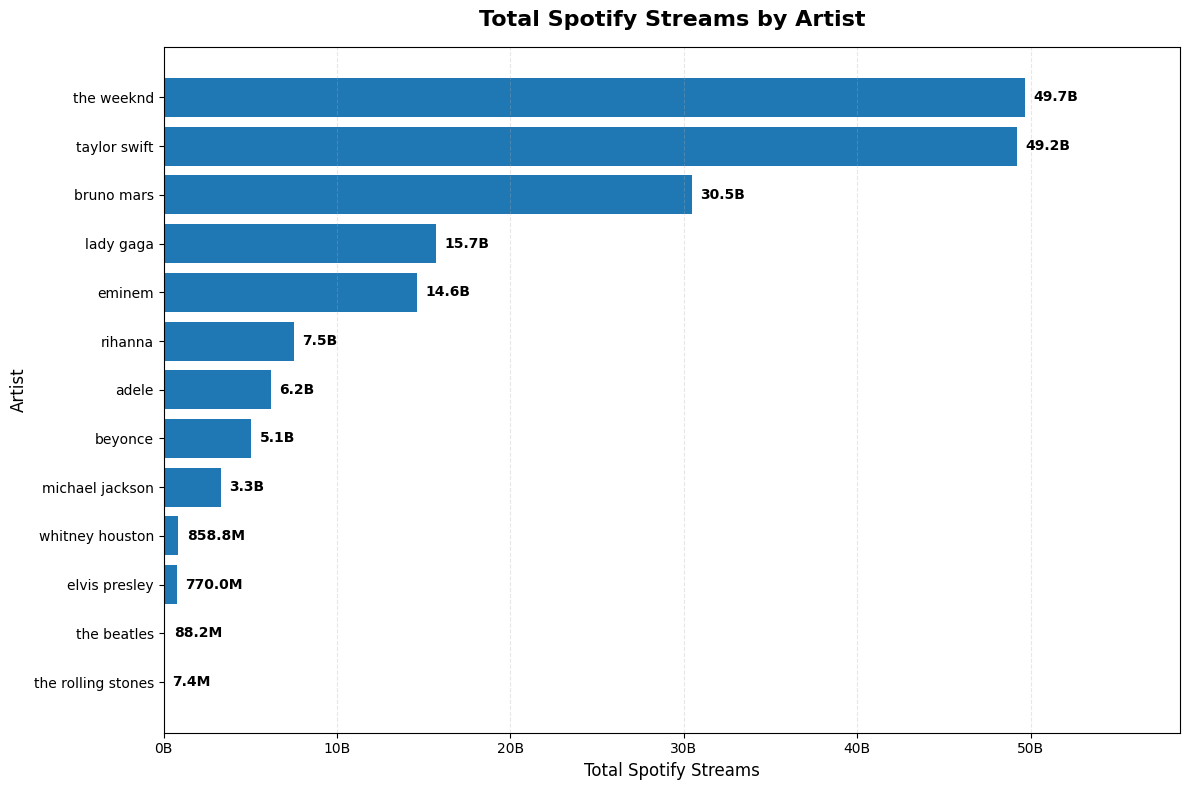

In [30]:
stream_plot = (
    stream_stats[["artist", "total_streams"]]
    .sort_values("total_streams", ascending=True)
    .reset_index(drop=True)
)
def format_streams(x):
    if x >= 1_000_000_000:
        return f"{x/1_000_000_000:.1f}B"
    elif x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.1f}K"
    else:
        return f"{int(x)}"
max_stream = stream_plot["total_streams"].max()
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(
    stream_plot["artist"],
    stream_plot["total_streams"]
)
for bar, value in zip(bars, stream_plot["total_streams"]):
    ax.text(
        value + max_stream * 0.01,
        bar.get_y() + bar.get_height() / 2,
        format_streams(value),
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000_000:.0f}B")
)
ticks = np.arange(
    0,
    max_stream * 1.21,
    10_000_000_000
)
ax.set_xticks(ticks)
ax.set_xlim(
    0,
    max_stream * 1.18
)
ax.set_title(
    "Total Spotify Streams by Artist",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel(
    "Total Spotify Streams",
    fontsize=12
)
ax.set_ylabel(
    "Artist",
    fontsize=12
)
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)
plt.tight_layout()
plt.show()

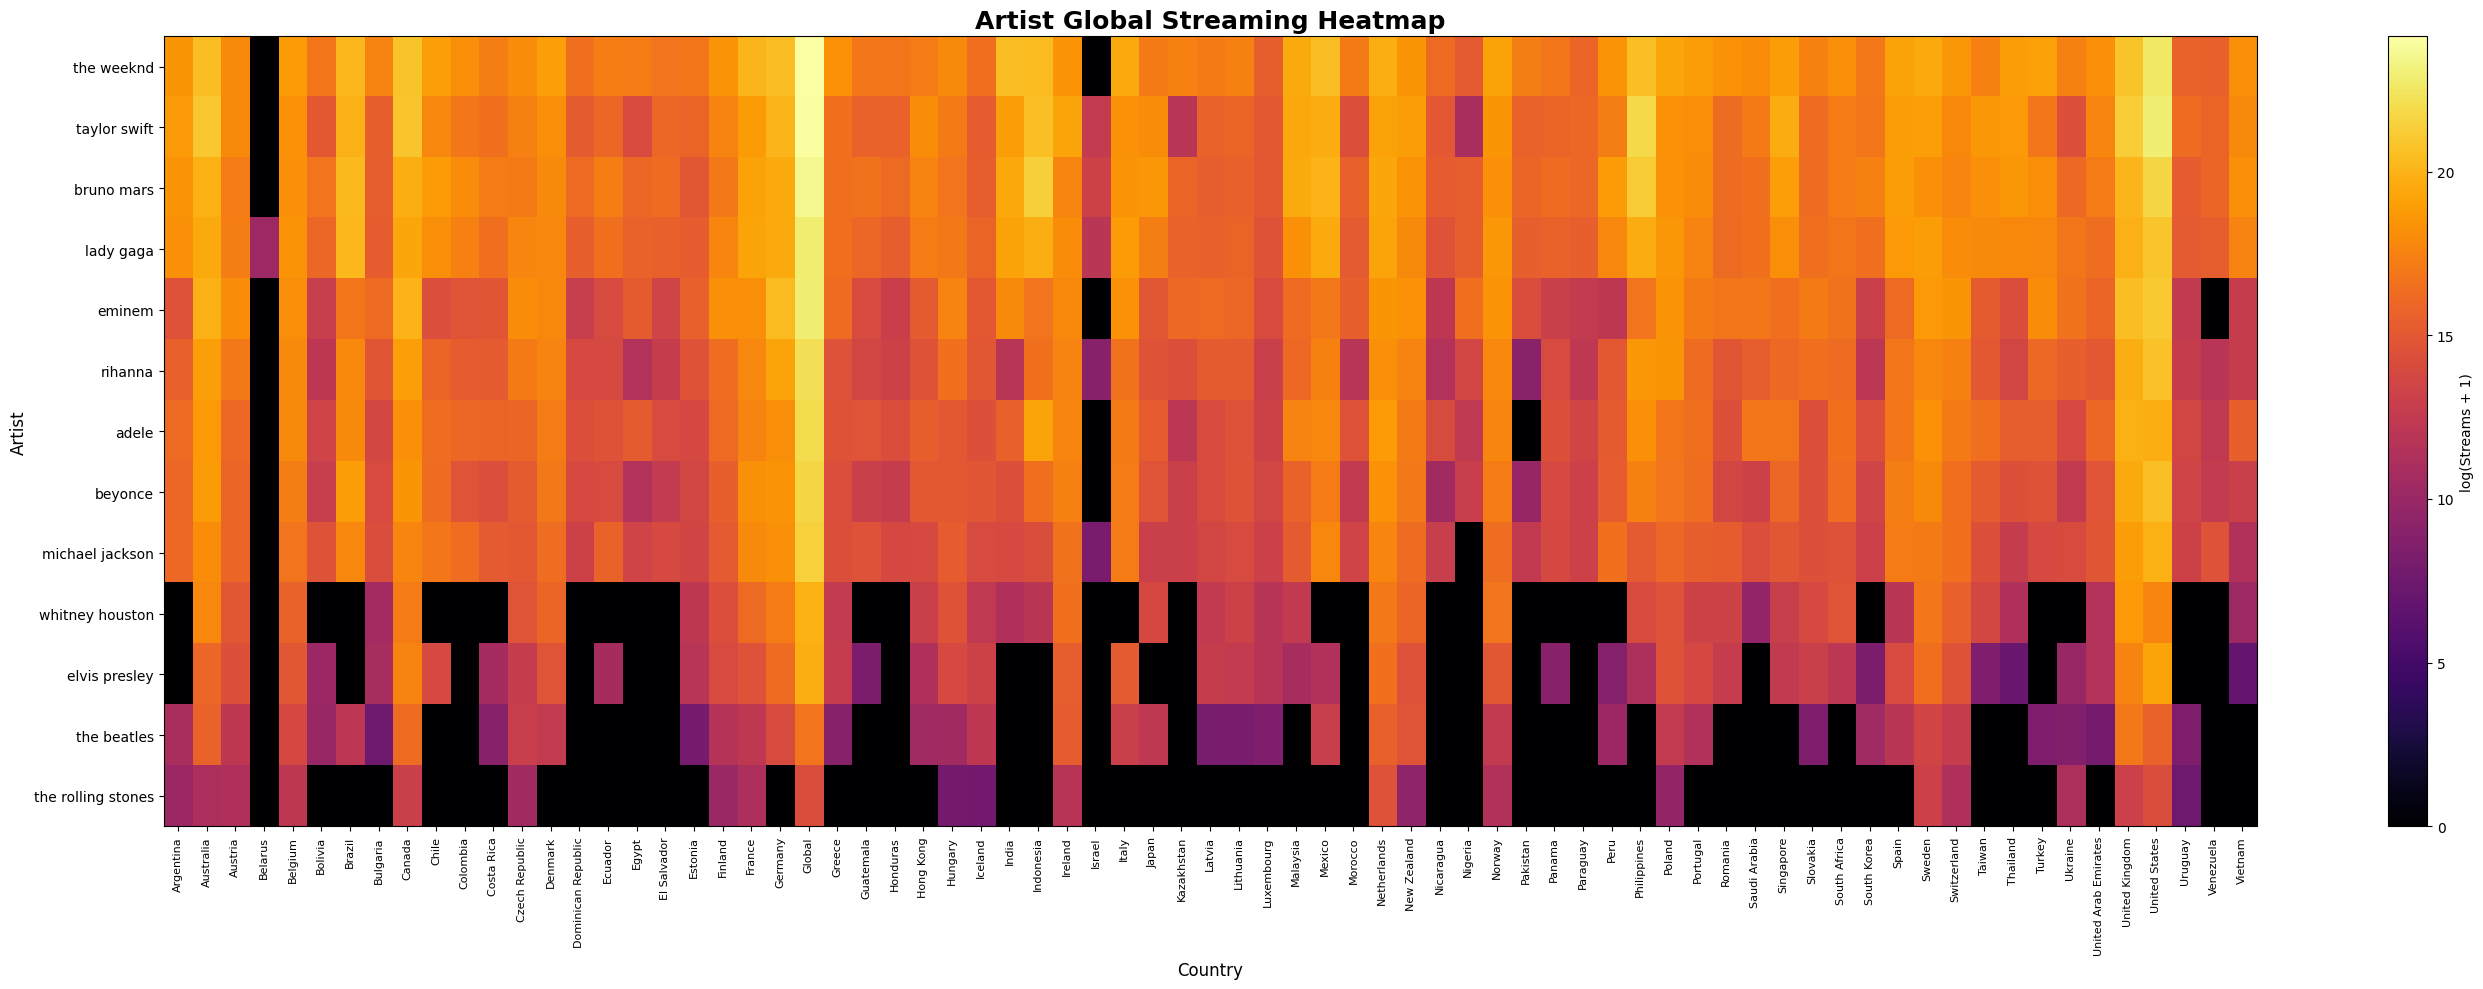

In [31]:
df = pd.read_csv("charts_songs_daily_targets.csv")
if not isinstance(df["artist_list"].iloc[0], list):
    df["artist_list"] = df["artist_list"].apply(literal_eval)
df["country"]=df["country"].astype(str).str.strip()
artist_rows=[]
for row in df.itertuples(index=False):
    matched_artists=[
        a
        for a in row.artist_list
        if a in TARGET_SET
    ]
    for artist in matched_artists:
        artist_rows.append(
            (
                artist,
                row.country,
                row.streams
            ))
credit_df=pd.DataFrame(
    artist_rows,
    columns=[
        "artist",
        "country",
        "streams"
    ])
heatmap_df=(
    credit_df
    .groupby(
        ["artist","country"],
        as_index=False
    )["streams"]
    .sum()
)
pivot=(
    heatmap_df
    .pivot(
        index="artist",
        columns="country",
        values="streams"
    )
    .fillna(0)
)
artist_order=(
    stream_stats
    .sort_values(
        "total_streams",
        ascending=False
    )["artist"]
)
pivot=pivot.reindex(artist_order)
plt.figure(figsize=(28,10))
plt.imshow(
    np.log1p(pivot.values),
    cmap="inferno",
    aspect="auto",
    interpolation="nearest"
)
plt.colorbar(label="log(Streams + 1)")
plt.xticks(
    np.arange(len(pivot.columns)),
    pivot.columns,
    rotation=90,
    fontsize=8
)
plt.yticks(
    np.arange(len(pivot.index)),
    pivot.index,
    fontsize=10
)
plt.title(
    "Artist Global Streaming Heatmap",
    fontsize=18,
    weight="bold"
)
plt.xlabel("Country",fontsize=12)
plt.ylabel("Artist",fontsize=12)
plt.tight_layout()
plt.show()

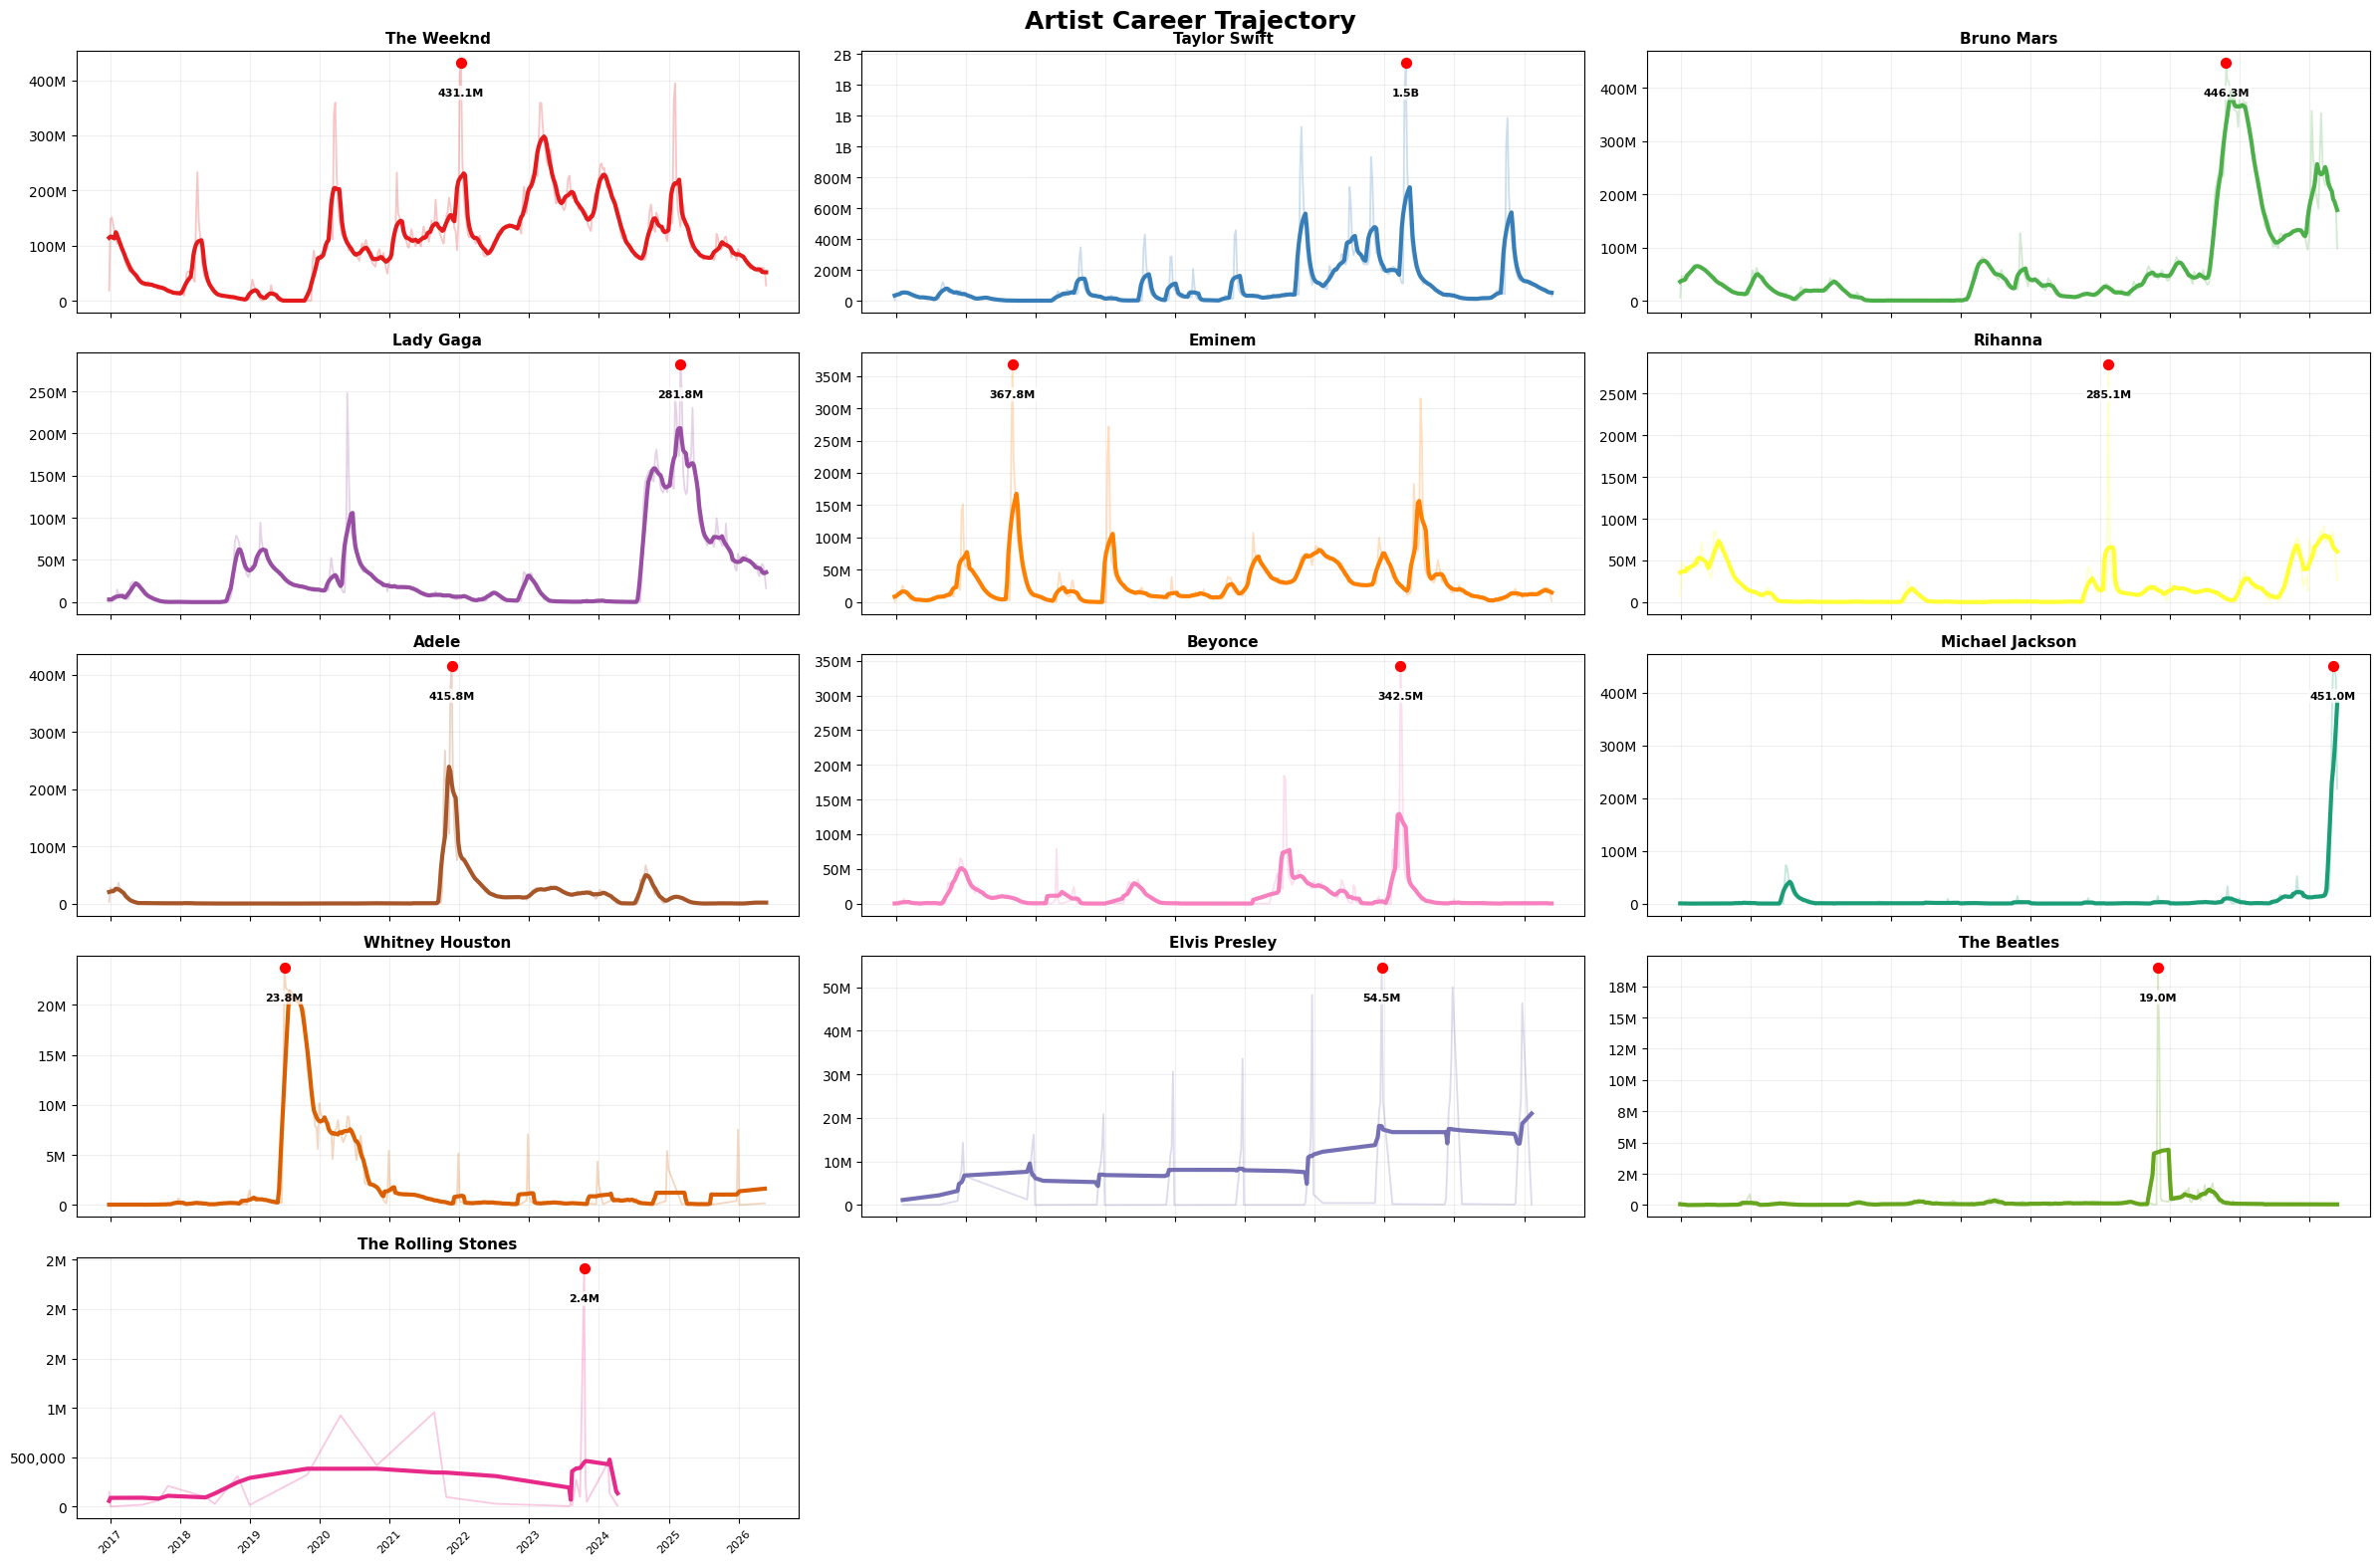

In [32]:
palette=[
"#E41A1C","#377EB8","#4DAF4A","#984EA3",
"#FF7F00","#FFFF33","#A65628","#F781BF",
"#1B9E77","#D95F02","#7570B3","#66A61E",
"#E7298A"
]
fig,axes=plt.subplots(5,3,figsize=(24,16),sharex=True)
axes=axes.flatten()
top_artists=(
    stream_stats
    .sort_values("total_streams",ascending=False)["artist"]
    .tolist()
)
used=0
for i,artist in enumerate(top_artists):
    temp=weekly_df[
        weekly_df["artist"]==artist
    ].copy()
    if len(temp)<2:
        continue
    temp["week_start"]=pd.to_datetime(
        temp["week"].astype(str).str.split("/").str[0]
    )
    temp=temp.sort_values("week_start")
    x=temp["week_start"]
    y=temp["weekly_streams"].astype(float)
    y_smooth=(
        y.rolling(
            window=8,
            center=True,
            min_periods=1
        ).mean()
    )
    peak_idx=y.idxmax()
    peak_x=temp.loc[peak_idx,"week_start"]
    peak_y=temp.loc[peak_idx,"weekly_streams"]
    c=palette[i%len(palette)]
    axes[used].plot(
        x,
        y,
        color=c,
        alpha=0.25,
        linewidth=1.3
    )
    axes[used].plot(
        x,
        y_smooth,
        color=c,
        linewidth=3
    )
    axes[used].scatter(
        peak_x,
        peak_y,
        color="red",
        s=50,
        zorder=5
    )
    label=(
        f"{peak_y/1e9:.1f}B"
        if peak_y>=1e9
        else(
            f"{peak_y/1e6:.1f}M"
            if peak_y>=1e6
            else f"{peak_y:,.0f}"
        ))
    offset = -18 if peak_y > y.max()*0.90 else 10
    axes[used].annotate(
    label,
    xy=(peak_x, peak_y),
    xytext=(0, offset),
    textcoords="offset points",
    ha="center",
    va="bottom" if offset > 0 else "top",
    fontsize=8,
    weight="bold",
    bbox=dict(
        boxstyle="round,pad=0.2",
        facecolor="white",
        edgecolor="none",
        alpha=0.75
    ))
    axes[used].set_title(
        artist.title(),
        fontsize=11,
        weight="bold"
    )
    axes[used].grid(alpha=0.20)
    axes[used].xaxis.set_major_locator(
        mdates.YearLocator()
    )
    axes[used].xaxis.set_major_formatter(
        mdates.DateFormatter("%Y")
    )
    axes[used].tick_params(
        axis="x",
        rotation=45,
        labelsize=8
    )
    axes[used].yaxis.set_major_formatter(
        mtick.FuncFormatter(
            lambda v,pos:
            f"{v/1e9:.0f}B"
            if v>=1e9
            else(
                f"{v/1e6:.0f}M"
                if v>=1e6
                else f"{v:,.0f}"
            )))
    used+=1
for j in range(used,len(axes)):
    fig.delaxes(axes[j])
fig.suptitle(
    "Artist Career Trajectory",
    fontsize=18,
    weight="bold"
)
plt.tight_layout()
plt.show()

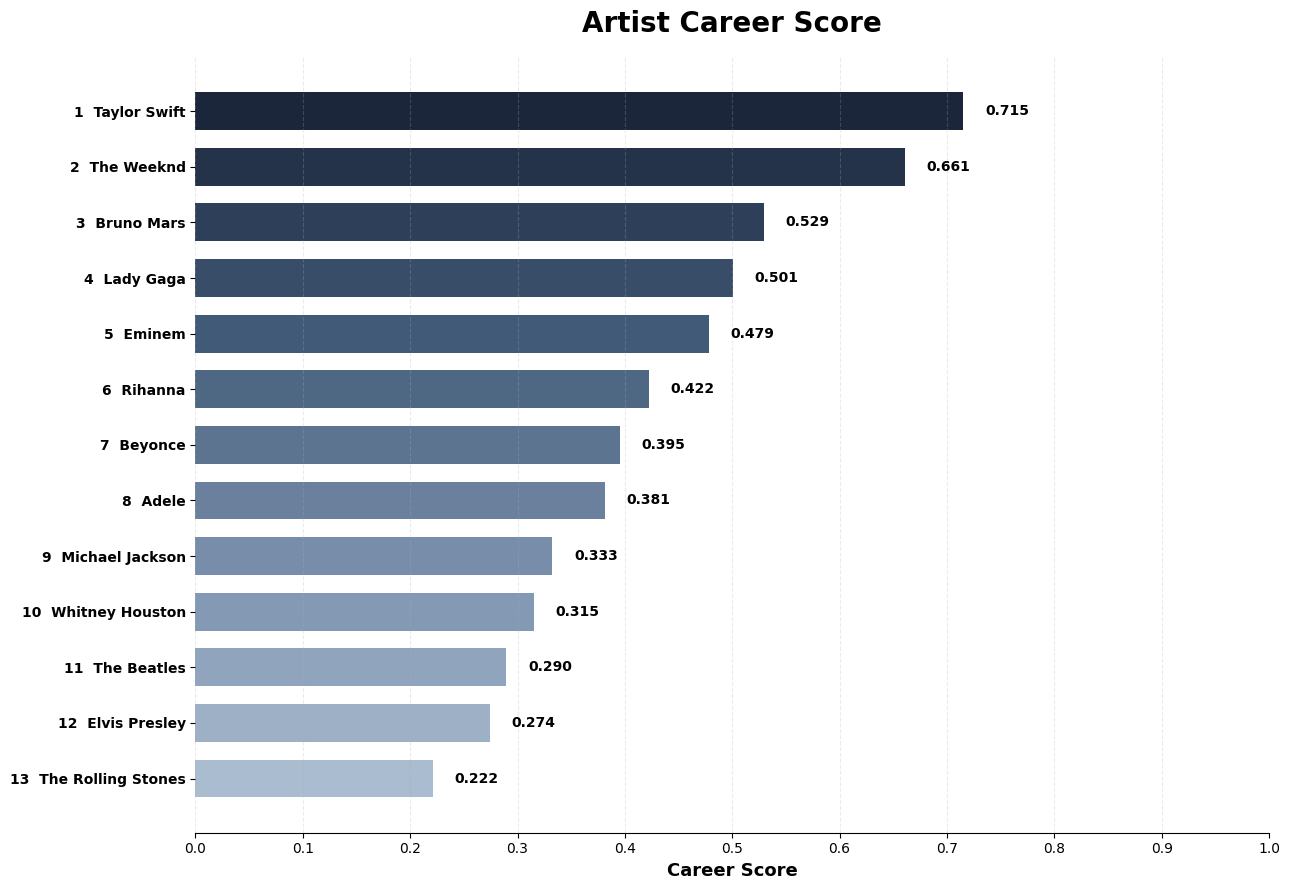

In [33]:
plot_df=final_ranking.copy()
plot_df=plot_df.sort_values(
    "career_score",
    ascending=False
).reset_index(drop=True)
fig,ax=plt.subplots(figsize=(13,9))
dark_slate=[
    "#1B263B",
    "#415A77",
    "#778DA9",
    "#A9BCD0"
]
cmap=LinearSegmentedColormap.from_list(
    "career_gradient",
    dark_slate
)
colors=cmap(
    np.linspace(
        0,
        1,
        len(plot_df)
    )
)
bars=ax.barh(
    np.arange(len(plot_df)),
    plot_df["career_score"],
    color=colors,
    edgecolor="none",
    height=0.68
)
ax.set_yticks(
    np.arange(len(plot_df))
)
ax.set_yticklabels(
    [
        f"{r}  {a.title()}"
        for r,a in zip(
            plot_df["rank"],
            plot_df["artist"]
        )
    ],
    fontsize=10,
    weight="bold"
)
ax.invert_yaxis()
for bar,score in zip(
    bars,
    plot_df["career_score"]
):
    x=bar.get_width()
    y=bar.get_y()+bar.get_height()/2
    ax.text(
        x+0.02,
        y,
        f"{score:.3f}",
        va="center",
        fontsize=10,
        weight="bold"
    )
ax.set_xlim(
    0,
    1
)
ax.set_xticks(
    np.arange(0,1.1,0.1)
)
ax.set_xlabel(
    "Career Score",
    fontsize=13,
    weight="bold"
)
ax.set_ylabel("")
ax.set_title(
    "Artist Career Score",
    fontsize=20,
    weight="bold",
    pad=18
)
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.tight_layout()
plt.show()